# Calibration

This notebook will go over an example on how to calibrate the MRR2. While the calibration constant in the Metek processing is entered in at the software level, with no support to reprocess using a new calibration constant, both IMProToo and RaProM support post-acquisition reprocessing of data for calibration. In this notebook, we will go over how to use co-incident disdrometer observations to calibrate the MRR2.

In [85]:
import xarray as xr
import matplotlib.pyplot as plt
import xradar as xd
import raprom
import rainrate_from_improtoo
import numpy as np
import IMProToo
import pandas as pd

from sklearn.linear_model import LinearRegression

Reload all of our datasets that we made in the previous chapter.

In [139]:
ds_metek = xr.open_dataset('../data/0520.pro', engine='metek')
ds = xr.open_dataset('../data/0520-processed.nc')
improtoo_spec = xr.open_dataset("0520.improtoo.nc")
improtoo_spec = improtoo_spec.set_coords(["time", "height"])

Load the $Parsivel^2$ data.

In [78]:
parsivel = xr.open_dataset('../data/crocus.adm.parsivel.20250520.000000.b1.nc')
parsivel

<xarray.Dataset> Size: 1MB
Dimensions:                      (time: 1440, bins: 32, bin_edges: 33)
Coordinates:
  * time                         (time) datetime64[ns] 12kB 2025-05-19T23:56:...
  * bins                         (bins) float64 256B 0.06225 0.1895 ... 25.24
  * bin_edges                    (bin_edges) float64 264B 0.0 0.1245 ... 26.78
Data variables: (12/29)
    velocity                     (time, bins) float64 369kB ...
    Nd                           (time, bins) float64 369kB ...
    num_particles                (time) int64 12kB ...
    spectrum_fall_velocity       (time, bins) float64 369kB ...
    rain_rate                    (time) float64 12kB ...
    Zh                           (time) float64 12kB ...
    ...                           ...
    power_supply_voltage         (time) float64 12kB ...
    sensor_head_heating_current  (time) float64 12kB ...
    sensor_heating_temperature   (time) int64 12kB ...
    temperature_right_head       (time) int64 12kB ...
    temperature_left_head        (time) int64 12kB ...
    sensor_time                  (time) datetime64[ns] 12kB ...
Attributes:
    site:                Argonne Deployable Mast
    mentors:             Liz Wawrzyniak, Joseph O'Brien, Bobby Jackson, Bhupe...
    mentor_emails:       ewawrzyniak@anl.gov, obrienj@anl.gov, rjackson@anl.g...
    mentor_institution:  Argonne National Laboratory
    mentor_orcids:       0000-0003-4655-6912, 0000-0003-2518-1234
    contributors:        Scott Collis, Paytsar Muradyan, Max Grover, Matt Tuf...

## Bias estimation

We will calibrate the MRR against the Parsivel by comparing the retrieved rainfall rates from the MRR at the lowest processed height against the $Parsivel^{2}$. If there is a systematic bias, we will multiply the calibration constant by that factor. First, we need to calculate rainfall rates from the IMProToo-processed spectra. Included with this repository is a module that calculates the rainfall rates using the same methodology that is in the Metek-provided software.

In [142]:
imptoo_rr = rainrate_from_improtoo.rainrate_from_improtoo(improtoo_spec)

Let's look at a time series plot of the rainfall rates. We will look at the third gate above the radar where there is consistent data available from all of the processing techniques (450 m). We are assuming here that the raindrop size distribution does not change significantly below 450 m, which can break down under high turbulence conditions.

In [ ]:
time_range = ('2025-05-20T08:30:00', '2025-05-20T11:30:00')
fig, ax = plt.subplots(1, 1, figsize=(9, 3))
parsivel['rain_rate'].sel(time=slice(time_range[0], time_range[1])).plot(label='Parsivel')
ds['RR'].isel(Height=2).sel(time=slice(time_range[0], time_range[1])).plot(label='RaProM')
ds_metek['rainfall_rate'].sel(time=slice(time_range[0], time_range[1])).isel(range=2).plot(label='Metek Processing')
imptoo_rr.isel(range=2).sel(time=slice(time_range[0], time_range[1])).plot(label="IMProToo")
plt.legend()

What sticks out here is that:

* For the heaviest rainfall rates (above about 10 mm/hr), the ImProToo and Metek processing underestimate the $Parsivel^{2}$. This is likely due to attenuation of the radar beam, which can strongly affect the retrieved DSD during convective rainfall events.
* RaProM consistently underestimates the rainfall rates.
* There is an apparent lag between the MRR2 and the Parsivel (though not consistent).

Let's compare the rainfall rates from the 450 m level of each technique against the $Parsivel^{2}$ to get an idea of how hot the MRR is running. If we see a consistent, systematic bias, this is indicative of a calibration issue.

Text(0, 0.5, 'RaProM Rain Rate [$mm\\ hr^{-1}$]')

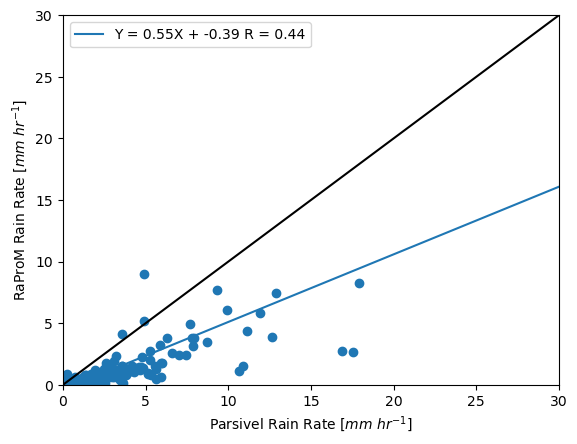

In [140]:
time_range = pd.date_range('2025-05-20T00:00:00', '2025-05-21T00:00:00', periods=1440)
x = parsivel['rain_rate'].reindex(time=time_range, method='nearest')

# Let's restrict to stratiform rain (35 dBZ and below)
y = ds['RR'].where(ds['Ze'] < 35.).isel(Height=2).reindex(time=time_range, method='nearest')
x, y = xr.align(x, y)
x = x.values.flatten()
y = y.values.flatten()
valid_points = np.logical_and(x > 0, y > 0)
linear_regression_model = LinearRegression()
linear_regression_model.fit(x[valid_points, np.newaxis],
                            y[valid_points])
R = linear_regression_model.score(x[valid_points, np.newaxis], y[valid_points])
plt.scatter(x, y)
plt.ylim([0, 30])
plt.xlim([0, 30])
plt.plot([0, 30], [0, 30], color='k')
xlim = np.array([0, 30])[:, np.newaxis]
m = linear_regression_model.coef_[0]
b = linear_regression_model.intercept_

plt.plot([0, 30], linear_regression_model.predict(xlim), label=f"Y = {m:2.2f}X + {b:2.2f} R = {R:0.2f}")
plt.legend()
plt.xlabel("Parsivel Rain Rate [$mm\ hr^{-1}$]")
plt.ylabel("RaProM Rain Rate [$mm\ hr^{-1}$]")

Text(0, 0.5, 'Metek Rain Rate [$mm\\ hr^{-1}$]')

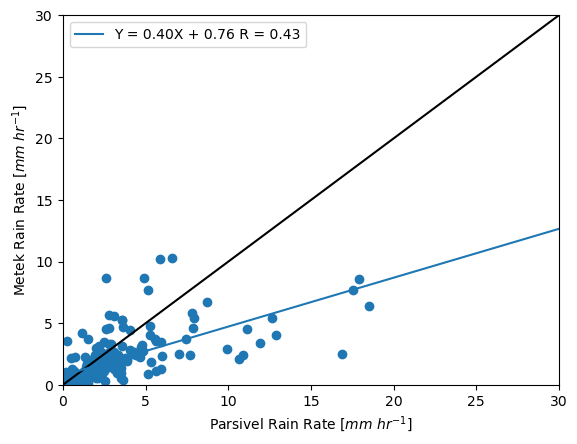

In [137]:
time_range = pd.date_range('2025-05-20T00:00:00', '2025-05-21T00:00:00', periods=1440)
x = parsivel['rain_rate'].reindex(time=time_range, method='nearest')
x = x.values.flatten()
y = ds_metek['rainfall_rate'].where(
    ds_metek['corrected_reflectivity'] < 35.).isel(range=2).reindex(time=time_range, method='nearest').values.flatten()
valid_points = np.logical_and(x > 0, y > 0)
linear_regression_model = LinearRegression()
linear_regression_model.fit(x[valid_points, np.newaxis],
                            y[valid_points])
R = linear_regression_model.score(x[valid_points, np.newaxis], y[valid_points])
plt.scatter(x, y)
plt.ylim([0, 30])
plt.xlim([0, 30])
plt.plot([0, 30], [0, 30], color='k')
xlim = np.array([0, 30])[:, np.newaxis]
m = linear_regression_model.coef_[0]
b = linear_regression_model.intercept_

plt.plot([0, 30], linear_regression_model.predict(xlim), label=f"Y = {m:2.2f}X + {b:2.2f} R = {R:0.2f}")
plt.legend()
plt.ylim([0, 30])
plt.xlim([0, 30])
plt.xlabel("Parsivel Rain Rate [$mm\ hr^{-1}$]")
plt.ylabel("Metek Rain Rate [$mm\ hr^{-1}$]")

Text(0, 0.5, 'ImProToo Rain Rate [$mm\\ hr^{-1}$]')

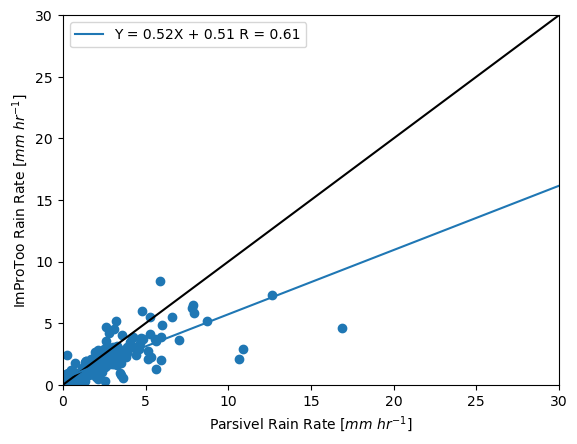

In [143]:
time_range = pd.date_range('2025-05-20T00:00:00', '2025-05-21T00:00:00', periods=1440)
x = parsivel['rain_rate'].reindex(time=time_range, method='nearest')
x = x.values.flatten()
y = imptoo_rr.where(improtoo_spec['Ze'] < 35.).reindex(time=time_range, method='nearest').isel(range=2).values.flatten()
valid_points = np.logical_and(x > 0, y > 0)
linear_regression_model = LinearRegression()
linear_regression_model.fit(x[valid_points, np.newaxis],
                            y[valid_points])
R = linear_regression_model.score(x[valid_points, np.newaxis], y[valid_points])
plt.scatter(x, y)
plt.ylim([0, 30])
plt.xlim([0, 30])
plt.plot([0, 30], [0, 30], color='k')
xlim = np.array([0, 30])[:, np.newaxis]
m = linear_regression_model.coef_[0]
b = linear_regression_model.intercept_
plt.plot([0, 30], linear_regression_model.predict(xlim), label=f"Y = {m:2.2f}X + {b:2.2f} R = {R:0.2f}")
plt.legend()
plt.xlabel("Parsivel Rain Rate [$mm\ hr^{-1}$]")
plt.ylabel("ImProToo Rain Rate [$mm\ hr^{-1}$]")

The above analyses suggest that the MRR2 is running about a factor of 2 too cold, or about 3 dBZ cold. We can use this information to reprocess the data with this new multiplicative factor of 2.

Reprocess using RaProM. Note, a quirk of this...the calibration "multiplicative" factor is actually 1/the input! So, if we need to multiply the calibration constant by 2, we should enter 0.5.

In [129]:
raprom_calib_path = raprom.process_file('../data/0520.raw', calibration=0.5)

File in process  /Users/rjackson/MRR-Processing-Intercomparison/data/0520
2026-06-05 17:16:41.555652
2026-06-05 17:17:37.535948




In [130]:
raprom_calib_ds = xr.open_dataset(raprom_calib_path)

Let's plot out the rain rates from the calibrated products. We can now see that the rain rate closure is much closer for both the RaProM and IMProToo processing methods.

Text(0, 0.5, 'RaProM Rain Rate [$mm\\ hr^{-1}$]')

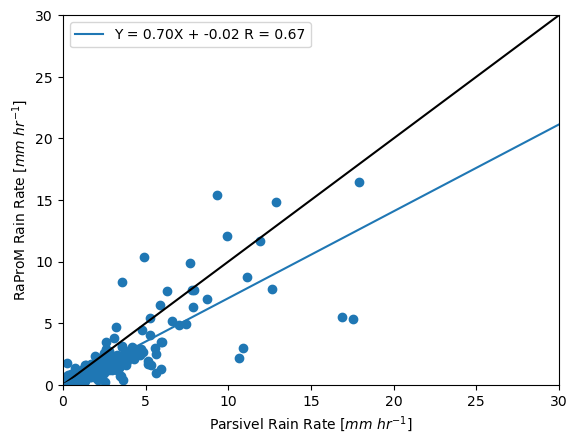

In [133]:
time_range = pd.date_range('2025-05-20T00:00:00', '2025-05-21T00:00:00', periods=1440)
x = parsivel['rain_rate'].reindex(time=time_range, method='nearest')
x = x.values.flatten()

# Let's restrict to stratiform rain (35 dBZ and below)
y = raprom_calib_ds['RR'].where(raprom_calib_ds["Ze"] < 35).reindex(time=time_range, method='nearest').isel(Height=2).values.flatten()
valid_points = np.logical_and(x > 0, y > 0)
linear_regression_model = LinearRegression()
linear_regression_model.fit(x[valid_points, np.newaxis],
                            y[valid_points])
R = linear_regression_model.score(x[valid_points, np.newaxis], y[valid_points])
plt.scatter(x, y)
plt.ylim([0, 30])
plt.xlim([0, 30])
plt.plot([0, 30], [0, 30], color='k')
xlim = np.array([0, 30])[:, np.newaxis]
m = linear_regression_model.coef_[0]
b = linear_regression_model.intercept_

plt.plot([0, 30], linear_regression_model.predict(xlim), label=f"Y = {m:2.2f}X + {b:2.2f} R = {R:0.2f}")
plt.legend()
plt.xlabel("Parsivel Rain Rate [$mm\ hr^{-1}$]")
plt.ylabel("RaProM Rain Rate [$mm\ hr^{-1}$]")

Reprocess the data using IMProToo, multiplying the calibration constant by a factor of 2, consistent with the ~0.5 biases we saw above.

In [120]:
# Insert your calibration factor here
calib_factor = 2
improtoo_ds = IMProToo.mrrRawData("../data/0520.raw")
processed_spec = IMProToo.MrrZe(improtoo_ds)
processed_spec.averageSpectra(60)
processed_spec.co["mrrCalibConst"] *= calib_factor
processed_spec.co["ncCreator"] = "Robert Jackson, Argonne National Laboratory"
processed_spec.co["ncDescription"] = "MRR data from CROCUS Urban Canyons"
processed_spec.co["dealiaseSpectrum"] = True
# We then process the outputs
processed_spec.rawToSnow()
# Write the outputs to a netCDF file
processed_spec.writeNetCDF("0520.improtoo.calibrated.nc")

1 of 1: ../data/0520.raw


/Users/rjackson/miniforge3/envs/crocus_env/lib/python3.13/site-packages/IMProToo/core.py:1286: UserWarning: Dealiasing failed! peak boundaries fall out of spectrum. time step 613, peak number 15, most likely at height 18
  warnings.warn('Dealiasing failed! peak boundaries fall out of spectrum. time step '+str(


In [144]:
improtoo_spec = xr.open_dataset("0520.improtoo.calibrated.nc")
improtoo_spec = improtoo_spec.set_coords(["time", "height"])
imptoo_rr = rainrate_from_improtoo.rainrate_from_improtoo(improtoo_spec)

Here, the rain rate closure is very good!

Text(0, 0.5, 'ImProToo Rain Rate [$mm\\ hr^{-1}$]')

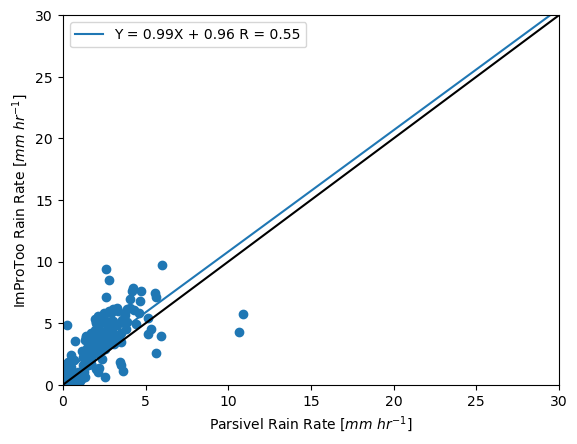

In [145]:
x = parsivel['rain_rate'].reindex(time=time_range, method='nearest').values.flatten()

# Let's restrict to stratiform rain (35 dBZ and below)
y = imptoo_rr.where(improtoo_spec["Ze"] < 35).reindex(time=time_range, method='nearest').isel(range=2).values.flatten()
valid_points = np.logical_and(x > 0, y > 0)
linear_regression_model = LinearRegression()
linear_regression_model.fit(x[valid_points, np.newaxis],
                            y[valid_points])
R = linear_regression_model.score(x[valid_points, np.newaxis], y[valid_points])
plt.scatter(x, y)
plt.ylim([0, 30])
plt.xlim([0, 30])
plt.plot([0, 30], [0, 30], color='k')
xlim = np.array([0, 30])[:, np.newaxis]
m = linear_regression_model.coef_[0]
b = linear_regression_model.intercept_

plt.plot([0, 30], linear_regression_model.predict(xlim), label=f"Y = {m:2.2f}X + {b:2.2f} R = {R:0.2f}")
plt.legend()
plt.xlabel("Parsivel Rain Rate [$mm\ hr^{-1}$]")
plt.ylabel("ImProToo Rain Rate [$mm\ hr^{-1}$]")

## Side-by-side comparison

Let's plot the reflectivity side by side. We should see about a 2-3 dBZ increase in the IMProToo and RaProM-generated reflectivity.

Text(0.5, 1.0, 'Factory processing')

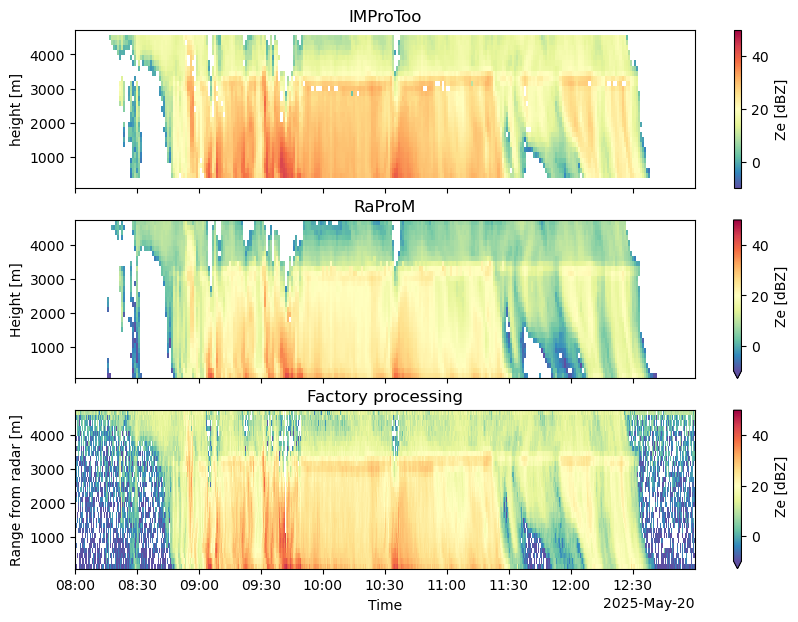

In [146]:
fig, ax = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
start_time = '2025-05-20T08:00:00'
end_time = '2025-05-20T13:00:00'
improtoo_spec['Ze'].sel(time=slice(start_time, end_time)).T.plot(
    cmap='Spectral_r', vmin=-10, vmax=50, y='height', ax=ax[0],
    cbar_kwargs={'label': 'Ze [dBZ]'})
raprom_calib_ds['Ze'].sel(time=slice(start_time, end_time)).T.plot(
    cmap='Spectral_r', vmin=-10, vmax=50, ax=ax[1],
    cbar_kwargs={'label': 'Ze [dBZ]'})
ds_metek['corrected_reflectivity'].sel(time=slice(start_time, end_time)).T.plot(
    cmap='Spectral_r', vmin=-10, vmax=50, ax=ax[2],
    cbar_kwargs={'label': 'Ze [dBZ]'})
ax[0].set_xlabel('')
ax[1].set_xlabel('')
ax[2].set_xlabel("Time")
ax[0].set_title("IMProToo")
ax[1].set_title("RaProM")
ax[2].set_title("Factory processing")

In [ ]:
The ImProToo